In [1]:
import os
from pathlib import Path

# ==================== Path Configuration ====================
# Model weights path
WEIGHTS_PATH = "./weights/best.pt"

# PS1 grizy 5-channel npy images directory
# Note: Only .npy format 5-channel images are supported
ORIGINAL_IMAGES_PATH = "./images"

# data.yaml path
DATA_YAML_PATH = "./data.yaml"

# ==================== Inference Parameters ====================
CONF_THRESHOLD = 0.4
IOU_THRESHOLD = 0.45
BATCH_SIZE = 16
DEVICE = "cpu"

print(f"✓ Weights path: {WEIGHTS_PATH}")
print(f"✓ Original images path: {ORIGINAL_IMAGES_PATH}")
print(f"✓ data.yaml path: {DATA_YAML_PATH}")

✓ Weights path: ./weights/best.pt
✓ Original images path: ./images
✓ data.yaml path: ./data.yaml


In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
import glob
import yaml

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


C:\conda\envs\envtest\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
C:\conda\envs\envtest\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
# Load data.yaml to get class information
print("Loading data.yaml...")
with open(DATA_YAML_PATH, 'r', encoding='utf-8') as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config.get('names', [])
print(f"✓ Number of classes: {len(CLASS_NAMES)}")
print(f"✓ Class names: {CLASS_NAMES}")

# Load YOLOv13-GF model
print(f"\nLoading model: {WEIGHTS_PATH}")
model = YOLO(WEIGHTS_PATH)
print(f"✓ Model loaded successfully")

Loading data.yaml...
✓ Number of classes: 1
✓ Class names: ['LT dwarf']

Loading model: ./weights/best.pt
✓ Model loaded successfully


In [9]:
# ==================== Step 1: YOLO Inference ====================
# Get all 5-channel npy images
image_paths = glob.glob(f"{ORIGINAL_IMAGES_PATH}/*.npy")

print(f"Found {len(image_paths)} 5-channel npy images")
if len(image_paths) == 0:
    print(f"⚠️ Warning: No .npy files found in {ORIGINAL_IMAGES_PATH} directory")
    print(f"Please ensure PS1 grizy 5-channel synthetic images are placed in images/ directory")

# Use model.predict for inference
# TXT files will be saved to: ./predict/labels/ directory
results = model.predict(
    source=ORIGINAL_IMAGES_PATH,
    stream=True,
    batch=BATCH_SIZE,
    device=DEVICE,
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    save=False,           # Do not save YOLO default result images
    save_conf=True,       # Save confidence
    save_txt=True,        # Save TXT files
    project='./',  # Project root directory
    exist_ok=True
)

# Collect inference results
all_results = []
for result in results:
    all_results.append(result)
    print(f"✓ {Path(result.path).name}: {len(result.boxes)} target")

print(f"\nTXT labels saved to ./predict/labels/")


Found 6 5-channel npy images

image 1/6 C:\Users\\Desktop\Detecting_L-T_dwarf_from_Pan-Starrs_survey_images\images\6.363888888888889_-3.1472222222222186.npy: 640x640 1 LT dwarf, 311.6ms
image 2/6 C:\Users\\Desktop\Detecting_L-T_dwarf_from_Pan-Starrs_survey_images\images\6.605555555555556_-1.5361111111111043.npy: 640x640 1 LT dwarf, 311.6ms
image 3/6 C:\Users\\Desktop\Detecting_L-T_dwarf_from_Pan-Starrs_survey_images\images\8.941666666666666_-1.61666666666666.npy: 640x640 1 LT dwarf, 311.6ms
image 4/6 C:\Users\\Desktop\Detecting_L-T_dwarf_from_Pan-Starrs_survey_images\images\cen6.355309371117_-3.16636791542673.npy: 640x640 1 LT dwarf, 311.6ms
image 5/6 C:\Users\\Desktop\Detecting_L-T_dwarf_from_Pan-Starrs_survey_images\images\cen6.605555555555556_-1.5361111111111043.npy: 640x640 1 LT dwarf, 311.6ms
image 6/6 C:\Users\\Desktop\Detecting_L-T_dwarf_from_Pan-Starrs_survey_images\images\cen8.941666666666666_-1.61666666666666.npy: 640x640 1 LT dwarf, 311.6ms
✓ 6.363888888888889_-3.14722222222

Found 6 TXT annotation files
✓ Combined annotation saved to: annotate_output\6.363888888888889_-3.1472222222222186_5channels_annotated.jpg
✓ Combined annotation saved to: annotate_output\6.605555555555556_-1.5361111111111043_5channels_annotated.jpg
✓ Combined annotation saved to: annotate_output\8.941666666666666_-1.61666666666666_5channels_annotated.jpg
✓ Combined annotation saved to: annotate_output\cen6.355309371117_-3.16636791542673_5channels_annotated.jpg
✓ Combined annotation saved to: annotate_output\cen6.605555555555556_-1.5361111111111043_5channels_annotated.jpg
✓ Combined annotation saved to: annotate_output\cen8.941666666666666_-1.61666666666666_5channels_annotated.jpg

Processing complete! Processed 6 files

Annotated channel images saved to: ./annotate_output/

Displaying 6 annotated images:


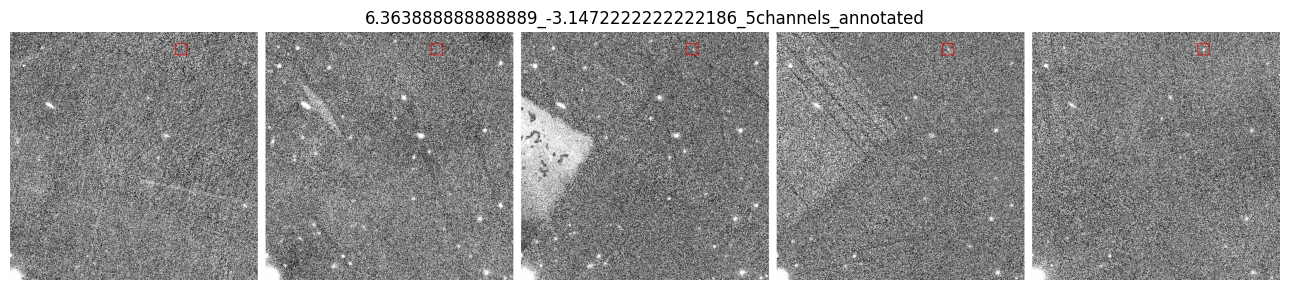

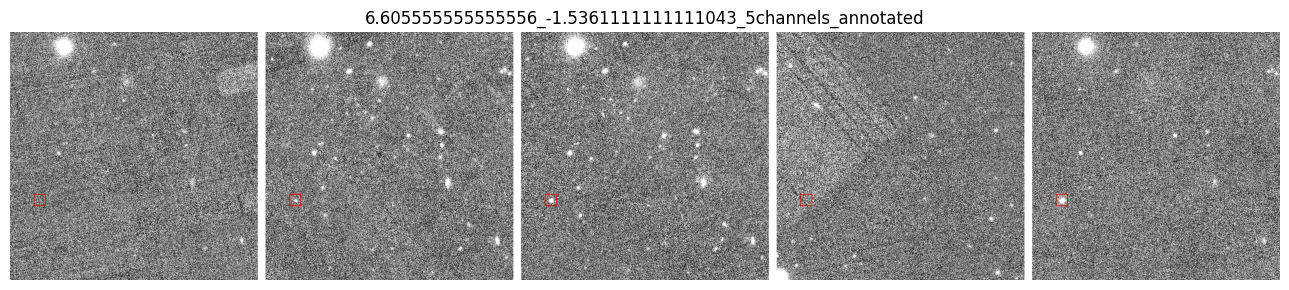

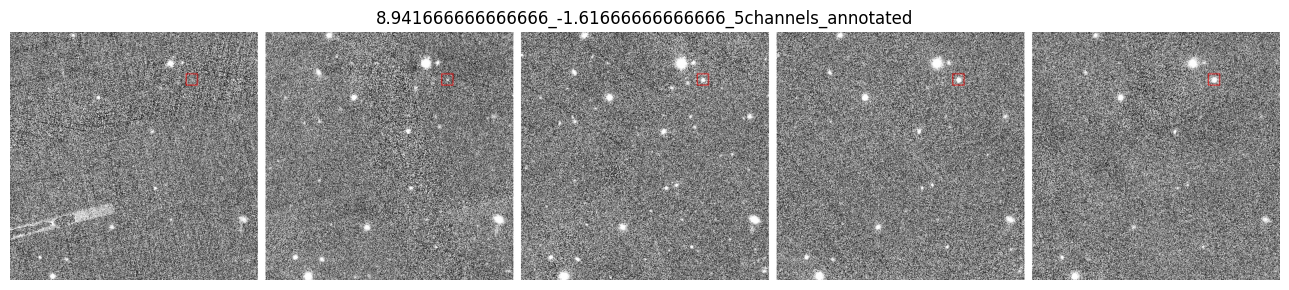

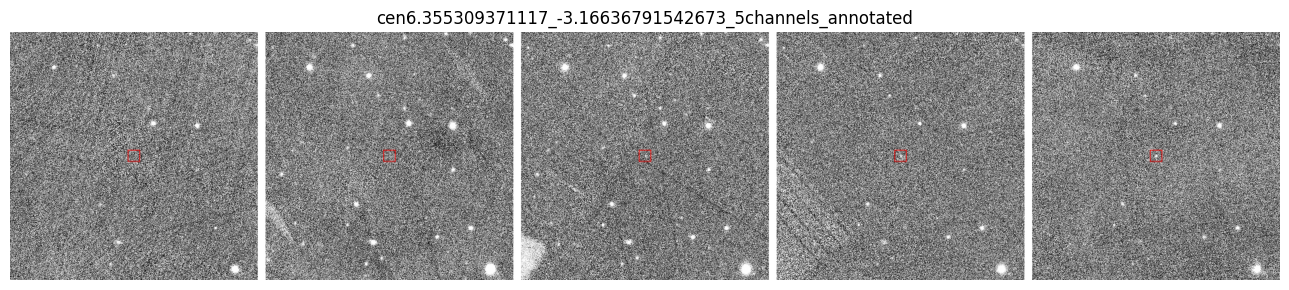

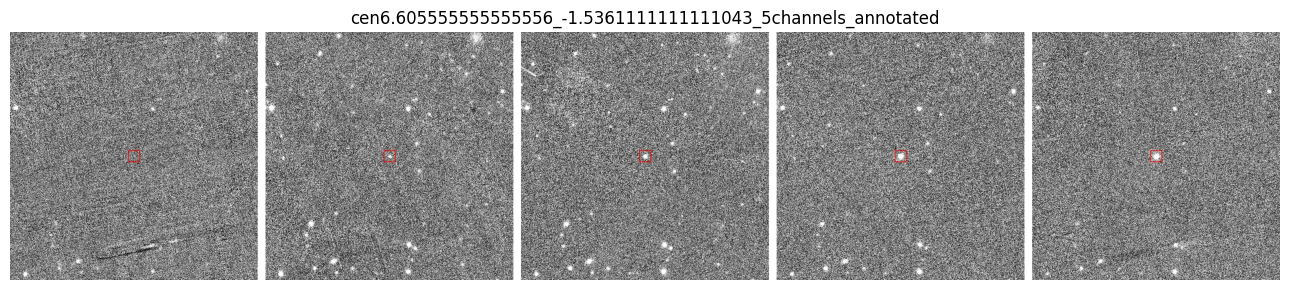

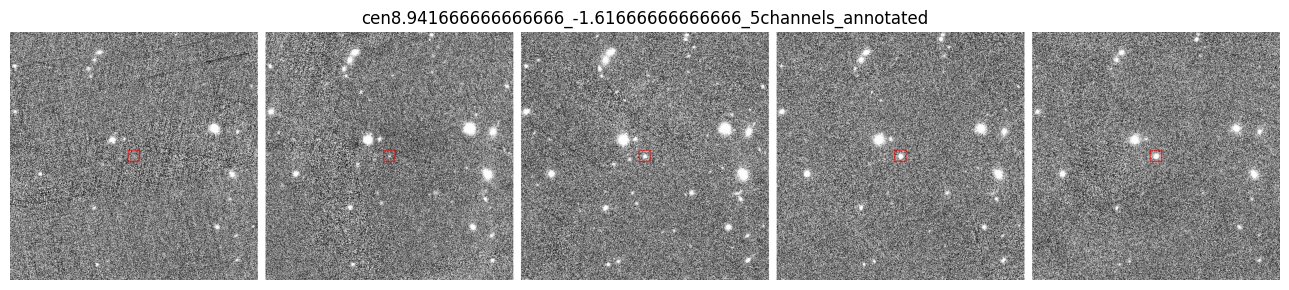

In [10]:
# ==================== Step 2: Channel Annotation and Visualization ====================
# Force reload the module to get latest changes
import importlib
import annotate_channels
importlib.reload(annotate_channels)
from annotate_channels import batch_annotate_from_txt
from PIL import Image
import glob

# Paths
NPY_DIR = "./images"
TXT_DIR = "./predict/labels"  # YOLO saved TXT files
SAVE_DIR = "./annotate_output"


# Process all npy files with their corresponding TXT annotations
annotation_results = batch_annotate_from_txt(
    npy_dir=NPY_DIR,
    txt_dir=TXT_DIR,
    class_names=CLASS_NAMES,
    save_dir=SAVE_DIR,
    show_plot=False
)

for result in annotation_results:
    img_name = Path(result['image_path']).name
    num_dets = len(result['detections'])

print(f"\nAnnotated channel images saved to: {SAVE_DIR}/")
print("="*60)

# ==================== Display Output Images (Max 6) ====================
output_images = sorted(glob.glob(f"{SAVE_DIR}/*.jpg"))
max_display = 6

print(f"\nDisplaying {min(len(output_images), max_display)} annotated images:")
print("="*60)

for i, img_path in enumerate(output_images[:max_display]):
    img = Image.open(img_path)
    plt.figure(figsize=(20, 3))
    plt.imshow(img)
    plt.title(f"{Path(img_path).stem}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if len(output_images) > max_display:
    print(f"\n... and {len(output_images) - max_display} more images in {SAVE_DIR}/")
